In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score

In [2]:
data=pd.read_csv("winequality-red.csv")

In [3]:
import sklearn
sklearn.__version__

'1.0.2'

In [4]:
data

,7.4,0.7,0,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5
0,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
1,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
2,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
3,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1594,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1595,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1596,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [5]:
data.columns=["a","b","c","d","e","f","g","h","i","j","k","Class"]
data

,a,b,c,d,e,f,g,h,i,j,k,Class
0,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
1,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
2,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
3,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1594,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1595,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1596,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [6]:
#data.drop('a', inplace=True, axis=1)

In [7]:
#data

In [8]:
data.Class = pd.factorize(data.Class)[0] + 1

In [9]:
gb=data.groupby("Class")

In [10]:
for Class, Class_df in gb:
    print(Class)
    print(Class_df)

1
        a      b     c    d      e     f     g        h     i     j     k  \
0     7.8  0.880  0.00  2.6  0.098  25.0  67.0  0.99680  3.20  0.68   9.8   
1     7.8  0.760  0.04  2.3  0.092  15.0  54.0  0.99700  3.26  0.65   9.8   
3     7.4  0.700  0.00  1.9  0.076  11.0  34.0  0.99780  3.51  0.56   9.4   
4     7.4  0.660  0.00  1.8  0.075  13.0  40.0  0.99780  3.51  0.56   9.4   
5     7.9  0.600  0.06  1.6  0.069  15.0  59.0  0.99640  3.30  0.46   9.4   
...   ...    ...   ...  ...    ...   ...   ...      ...   ...   ...   ...   
1581  6.1  0.715  0.10  2.6  0.053  13.0  27.0  0.99362  3.57  0.50  11.9   
1582  6.2  0.460  0.29  2.1  0.074  32.0  98.0  0.99578  3.33  0.62   9.8   
1588  6.6  0.725  0.20  7.8  0.073  29.0  79.0  0.99770  3.29  0.54   9.2   
1593  6.2  0.600  0.08  2.0  0.090  32.0  44.0  0.99490  3.45  0.58  10.5   
1596  5.9  0.645  0.12  2.0  0.075  32.0  44.0  0.99547  3.57  0.71  10.2   

      Class  
0         1  
1         1  
3         1  
4         1  
5  

In [11]:
gb.get_group(1)

,a,b,c,d,e,f,g,h,i,j,k,Class
0,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1
1,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1
3,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,1
5,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.99640,3.30,0.46,9.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1581,6.1,0.715,0.10,2.6,0.053,13.0,27.0,0.99362,3.57,0.50,11.9,1
1582,6.2,0.460,0.29,2.1,0.074,32.0,98.0,0.99578,3.33,0.62,9.8,1
1588,6.6,0.725,0.20,7.8,0.073,29.0,79.0,0.99770,3.29,0.54,9.2,1
1593,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,1


In [12]:
class_samples=gb.get_group(1).sample(n=15)
#    print(class_samples)

In [13]:
print(type(class_samples))

<class 'pandas.core.frame.DataFrame'>


In [14]:
mean_sum=class_samples["b"].mean() + class_samples["c"].mean() + class_samples["d"].mean() + class_samples["e"].mean() + class_samples["f"].mean() + class_samples["g"].mean() + class_samples["h"].mean() + class_samples["i"].mean() + class_samples["j"].mean() + class_samples["k"].mean() 

In [15]:
column_length=len(data.columns) -1

In [16]:
similar_val_1=mean_sum/column_length
print(similar_val_1)

6.874319757575757


In [17]:
class_2_samples=gb.get_group(2).sample(n=15)
#    print(class_2_samples)

In [18]:
mean_sum_2=class_2_samples["b"].mean() + class_2_samples["c"].mean() + class_2_samples["d"].mean() + class_2_samples["e"].mean() + class_2_samples["f"].mean() + class_2_samples["g"].mean() + class_2_samples["h"].mean() + class_2_samples["i"].mean() + class_2_samples["j"].mean()  + class_samples["k"].mean()

In [19]:
similar_val_2=mean_sum_2/column_length
print(similar_val_2)

6.263046060606061


In [20]:
class_3_samples=gb.get_group(3).sample(n=15)
#    print(class_3_samples)

In [21]:
mean_sum_3=class_3_samples["b"].mean() + class_3_samples["c"].mean() + class_3_samples["d"].mean() + class_3_samples["e"].mean() + class_3_samples["f"].mean() + class_3_samples["g"].mean() + class_3_samples["h"].mean() + class_3_samples["i"].mean() + class_3_samples["j"].mean()  + class_samples["k"].mean()

In [22]:
similar_val_3=mean_sum_3/column_length
print(similar_val_3)

5.169927636363636


In [23]:
class_4_samples=gb.get_group(4).sample(n=15)

In [24]:
mean_sum_4=class_4_samples["b"].mean() + class_4_samples["c"].mean() + class_4_samples["d"].mean() + class_4_samples["e"].mean() + class_4_samples["f"].mean() + class_4_samples["g"].mean() + class_4_samples["h"].mean() + class_4_samples["i"].mean() + class_4_samples["j"].mean()  + class_samples["k"].mean()

In [25]:
similar_val_4=mean_sum_4/column_length
print(similar_val_4)

5.942211272727274


In [26]:
class_5_samples=gb.get_group(5).sample(n=8)

In [27]:
mean_sum_5=class_5_samples["b"].mean() + class_5_samples["c"].mean() + class_5_samples["d"].mean() + class_5_samples["e"].mean() + class_5_samples["f"].mean() + class_5_samples["g"].mean() + class_5_samples["h"].mean() + class_5_samples["i"].mean() + class_5_samples["j"].mean()  + class_samples["k"].mean()

In [28]:
similar_val_5=mean_sum_5/column_length
print(similar_val_5)

6.841602386363636


In [29]:
class_6_samples=gb.get_group(6).sample(n=10)

In [30]:
mean_sum_6=class_6_samples["b"].mean() + class_6_samples["c"].mean() + class_6_samples["d"].mean() + class_6_samples["e"].mean() + class_6_samples["f"].mean() + class_6_samples["g"].mean() + class_6_samples["h"].mean() + class_6_samples["i"].mean() + class_6_samples["j"].mean() + class_6_samples["k"].mean()

In [31]:
similar_val_6 = mean_sum_6/column_length
print(similar_val_6)

4.9666785454545455


In [32]:
sim_23=abs(similar_val_3 - similar_val_2)
sim_23=sim_23/1000
sim_23=1 - sim_23

sim_24=abs(similar_val_2 - similar_val_4)
sim_24=sim_24/1000
sim_24=1 - sim_24

sim_25=abs(similar_val_2 - similar_val_5)
sim_25=sim_25/1000
sim_25=1 - sim_25

sim_26=abs(similar_val_2 - similar_val_6)
sim_26=sim_26/1000
sim_26=1 - sim_26

sim_12=abs(similar_val_1 - similar_val_2)
sim_12=sim_12/1000
sim_12=1 - sim_12

sim_13=abs(similar_val_3 - similar_val_1)
sim_13=sim_13/1000
sim_13=1 - sim_13

sim_14=abs(similar_val_1 - similar_val_4)
sim_14=sim_12/1000
sim_14=1 - sim_14

sim_15=abs(similar_val_1 - similar_val_5)
sim_15=sim_13/1000
sim_15=1 - sim_15

sim_16=abs(similar_val_1 - similar_val_6)
sim_16=sim_16/1000
sim_16=1 - sim_16

sim_34=abs(similar_val_3 - similar_val_4)
sim_34=sim_34/1000
sim_34=1 - sim_34

sim_35=abs(similar_val_3 - similar_val_5)
sim_35=sim_35/1000
sim_35=1 - sim_35

sim_36=abs(similar_val_3 - similar_val_6)
sim_36=sim_36/1000
sim_36=1 - sim_36

sim_45=abs(similar_val_4 - similar_val_5)
sim_45=sim_45/1000
sim_45=1 - sim_45

sim_46=abs(similar_val_4 - similar_val_6)
sim_46=sim_45/1000
sim_46=1 - sim_46

sim_56=abs(similar_val_5 - similar_val_6)
sim_56=sim_56/1000
sim_56=1 - sim_56


print("Similarity between 1 and 2: ", sim_12)
print("Similarity between 1 and 3: ", sim_13)
print("Similarity between 1 and 4: ", sim_14)
print("Similarity between 1 and 5: ", sim_15)
print("Similarity between 1 and 6: ", sim_16)

print("Similarity between 2 and 3: ", sim_23)
print("Similarity between 2 and 4: ", sim_24)
print("Similarity between 2 and 5: ", sim_25)
print("Similarity between 2 and 6: ", sim_26)

print("Similarity between 3 and 4: ", sim_34)
print("Similarity between 3 and 5: ", sim_35)
print("Similarity between 3 and 6: ", sim_36)

print("Similarity between 4 and 5: ", sim_45)
print("Similarity between 4 and 6: ", sim_46)

print("Similarity between 5 and 6: ", sim_56)

Similarity between 1 and 2:  0.9993887263030303
Similarity between 1 and 3:  0.9982956078787879
Similarity between 1 and 4:  0.999000611273697
Similarity between 1 and 5:  0.9990017043921212
Similarity between 1 and 6:  0.9980923587878788
Similarity between 2 and 3:  0.9989068815757576
Similarity between 2 and 4:  0.9996791652121212
Similarity between 2 and 5:  0.9994214436742425
Similarity between 2 and 6:  0.9987036324848485
Similarity between 3 and 4:  0.9992277163636364
Similarity between 3 and 5:  0.99832832525
Similarity between 3 and 6:  0.9997967509090909
Similarity between 4 and 5:  0.9991006088863637
Similarity between 4 and 6:  0.9990008993911136
Similarity between 5 and 6:  0.998125076159091


In [33]:
gb.size()

Class
1    680
2    638
3    199
4     53
5     18
6     10
dtype: int64

In [34]:
m=math.ceil((680+10)/2)

In [35]:
print(m)

345


In [36]:
len(gb)

6

In [37]:
neigh = KNeighborsClassifier(n_neighbors=5)

In [38]:
#neigh.fit(X_train, Y_train)
neigh.fit(data, data.Class)

KNeighborsClassifier()

In [39]:
result=neigh.kneighbors(data, return_distance=True)

In [40]:
print(type(result))

<class 'tuple'>


In [41]:
print(result)

(array([[0.        , 1.54385948, 2.67341458, 2.71625866, 2.71625866],
       [0.        , 1.25056949, 2.03008774, 2.10242742, 2.18040046],
       [0.        , 3.13075346, 3.13075346, 3.65030478, 3.73389997],
       ...,
       [0.        , 0.        , 2.13641523, 2.77120273, 3.65701049],
       [0.        , 0.463843  , 2.51760331, 2.54509119, 2.77126853],
       [0.        , 1.89385448, 1.89385448, 2.91786672, 3.10411125]]), array([[   0,  751, 1313, 1173, 1172],
       [   1,  195,   57, 1360,   62],
       [   2,  786,  787,  231,  691],
       ...,
       [1591, 1595, 1541, 1592, 1564],
       [1596, 1593, 1045,  669, 1272],
       [1597,  570,  568,  994, 1334]], dtype=int64))


In [42]:
arr1=result[0]

In [43]:
print(type(arr1))

<class 'numpy.ndarray'>


In [44]:
print(arr1.ndim)

2


In [45]:
arr2=result[1]

In [46]:
print(type(arr2))

<class 'numpy.ndarray'>


In [47]:
print(arr1.ndim)

2


In [48]:
print(arr2)

[[   0  751 1313 1173 1172]
 [   1  195   57 1360   62]
 [   2  786  787  231  691]
 ...
 [1591 1595 1541 1592 1564]
 [1596 1593 1045  669 1272]
 [1597  570  568  994 1334]]


In [49]:
print(arr1)

[[0.         1.54385948 2.67341458 2.71625866 2.71625866]
 [0.         1.25056949 2.03008774 2.10242742 2.18040046]
 [0.         3.13075346 3.13075346 3.65030478 3.73389997]
 ...
 [0.         0.         2.13641523 2.77120273 3.65701049]
 [0.         0.463843   2.51760331 2.54509119 2.77126853]
 [0.         1.89385448 1.89385448 2.91786672 3.10411125]]


In [50]:
#print(arr1)

In [51]:
print(arr1.size)

7990


In [52]:
#tHIS LINE TAKES THE SUMMATION OF A THE DISTANCE BETWEEN THE INSTANCE AND IT'S NEIGHBORS
addVal=[]
s=1
for i in arr1:
    _sum=int(i[0] + i[1] + i[2] + i[3] + i[4])
    addVal.append(_sum)
    print(i ," ", _sum, " ") 
    s=s+1

[0.         1.54385948 2.67341458 2.71625866 2.71625866]   9  
[0.         1.25056949 2.03008774 2.10242742 2.18040046]   7  
[0.         3.13075346 3.13075346 3.65030478 3.73389997]   13  
[0.         0.9305461  1.6799822  2.12212299 2.12212299]   6  
[0.         0.46800175 1.81540877 1.98281874 2.05221858]   6  
[0.         1.47689065 1.89833738 1.89833738 2.44910479]   7  
[0.         1.97377924 2.11994747 2.11994747 2.11994747]   8  
[0.         2.05215164 2.08780173 2.24275751 2.40054277]   8  
[0.         0.         4.32965366 4.49898546 4.61643638]   13  
[0.         1.1917978  1.4883595  2.39374742 2.45383256]   7  
[0.         0.         4.32965366 4.49898546 4.61643638]   13  
[0.         2.37628393 2.42853619 2.57414635 2.79026709]   10  
[0.         1.5466213  1.67668194 1.87792555 1.9374303 ]   7  
[ 0.          3.16429076 11.39501267 11.78652569 13.118904  ]   39  
[ 0.          3.16429076 12.25842102 12.50755093 14.40321234]   42  
[0.         2.80797602 3.26644817 3.905

[0.         1.9623649  1.97540407 2.68072921 2.68072921]   9  
[0.         0.         3.60505626 3.60505626 3.74554616]   10  
[0.         0.         2.62299486 3.20311431 3.26757849]   9  
[0.         0.         2.62299486 3.20311431 3.26757849]   9  
[0.         3.05768271 3.30028259 3.46876225 3.97011004]   13  
[0.         1.84223403 1.84223403 1.91084696 2.04150481]   7  
[0.         0.         1.73143579 1.8885776  2.40161451]   6  
[0.         5.66974323 5.74730407 6.82793423 6.9626185 ]   25  
[0.         0.         1.73143579 1.8885776  2.40161451]   6  
[0.         1.29127127 1.51229002 1.51229002 1.63602613]   5  
[0.         2.02375142 2.60956442 2.61908565 2.65312062]   9  
[0.         1.51327465 1.62674184 1.65752354 1.9435222 ]   6  
[0.         2.88774746 3.06537208 4.55186091 4.82439115]   15  
[0.         1.76371701 1.76371701 1.99859586 2.21774233]   7  
[0.         2.46004797 2.51355357 2.51355357 2.60563825]   10  
[0.         1.55239951 1.58541749 1.58541749 1.676

[0.         3.26863031 4.73260372 5.34181875 5.34181875]   18  
[0.         2.76548538 3.13731112 3.34172113 3.71840949]   12  
[0.         2.57612598 2.93091604 3.07111564 3.11447887]   11  
[0.         0.         2.82587395 4.70407946 4.74854568]   12  
[0.         3.00922602 3.19097633 4.27346804 4.55508083]   15  
[0.         2.4071947  2.4071947  3.3912736  3.59379599]   11  
[0.         0.         1.97532325 2.36843535 2.36843535]   6  
[0.         0.         4.19850938 4.19850938 4.39681191]   12  
[0.         0.         2.51775098 2.60461136 3.58069339]   8  
[0.         0.         2.51775098 2.60461136 3.58069339]   8  
[0.         2.7791879  2.93441012 2.93783424 3.53653889]   12  
[0.         1.54709498 1.8455593  1.9538031  2.10250437]   7  
[0.         0.         4.19850938 4.19850938 4.39681191]   12  
[0.         0.         1.97532325 2.36843535 2.36843535]   6  
[0.         1.43636129 1.49863615 1.49863615 1.61536199]   6  
[0.         4.17699665 4.89893424 5.00043407 5

[0.         3.19068974 4.51124695 4.82745098 5.32593034]   17  
[0.         0.         1.13401289 1.40289074 1.5802287 ]   4  
[0.         0.         1.49867409 1.74994304 1.74994304]   4  
[0.         0.93241635 1.71179032 1.9538031  2.24786   ]   6  
[0.         0.         1.49867409 1.74994304 1.74994304]   4  
[0.         0.93241635 1.23540491 1.71255729 1.80473518]   5  
[0.         3.09937241 4.34942276 6.4589408  7.76698116]   21  
[0.         2.1251168  2.59778436 2.67611021 2.70680624]   10  
[0.         3.61037431 3.61037431 3.61037431 4.03318125]   14  
[0.         0.99743125 1.84843113 1.87313261 2.10795851]   6  
[0.         2.64133287 3.15945719 3.17078923 3.3912736 ]   12  
[0.         0.         1.57125202 1.65133975 1.76188564]   4  
[0.         2.84880014 3.19068974 3.51529302 4.32616112]   13  
[0.         0.         1.57125202 1.65133975 1.76188564]   4  
[0.         0.46800175 1.93519107 2.10670626 2.15745596]   6  
[0.         1.76260221 2.05020642 2.05020642 2.15

[0.         1.75813477 2.49930502 2.59000855 2.59000855]   9  
[0.         0.         1.6538071  1.6538071  1.81203229]   5  
[0.         0.         1.6538071  1.6538071  1.81203229]   5  
[0.         0.         1.26203859 2.51514893 2.51514893]   6  
[0.         0.         1.26203859 2.51514893 2.51514893]   6  
[0.         2.32605481 3.18321728 3.31439665 4.2885567 ]   13  
[0.         2.35006476 3.01876219 3.6687438  3.75028082]   12  
[0.         2.53364092 2.58411385 2.58855102 2.60611313]   10  
[0.         1.25234545 1.81663768 2.68291911 2.98462797]   8  
[0.         0.         0.9731163  1.5985687  1.93046136]   4  
[0.         1.85047589 1.85047589 1.91273871 2.33309367]   7  
[0.         3.0122843  3.0122843  3.72742635 4.51600306]   14  
[0.         1.59328778 1.76543595 1.76543595 1.89521189]   7  
[0.         0.7989207  0.7989207  1.48345778 1.91273871]   4  
[0.         0.         0.9731163  1.5985687  1.93046136]   4  
[0.         1.424818   2.00166408 2.08607147 2.4543

[0.         1.94940611 2.08236168 2.37055823 2.62621191]   9  
[0.         1.2163343  1.53878015 1.53897272 1.65133975]   5  
[0.         1.52328032 1.61356822 1.63021523 1.71615888]   6  
[0.         1.11114277 1.30150067 1.64136601 1.67970039]   5  
[0.         1.2758233  1.52340442 1.62606175 1.63562893]   6  
[0.         1.86730728 2.00688841 2.00688841 2.40125259]   8  
[0.         0.         1.84437112 2.49514919 2.49514919]   6  
[0.         0.         1.84437112 2.49514919 2.49514919]   6  
[0.         1.91084696 1.93803415 2.01775034 2.01775034]   7  
[0.         1.96316098 1.96316098 2.43020658 2.55424696]   8  
[0.         0.         3.78594771 3.95676924 4.95032697]   12  
[0.         2.39662903 3.0979503  3.75638124 3.75638124]   13  
[0.         1.23900015 1.43047245 1.43047245 1.64292539]   5  
[0.         0.         3.78594771 3.95676924 4.95032697]   12  
[0.         4.690663   6.63700345 7.05995333 7.07179228]   25  
[0.         0.85538085 1.47143511 1.55775517 1.5577

[0.         2.19018854 2.98462797 3.19610024 3.20847643]   11  
[0.         1.24692673 1.54897552 1.68596054 2.28233758]   6  
[0.         2.75323925 2.96015627 3.09650276 3.18626602]   11  
[0.         2.1718266  2.30222029 3.22463085 3.32168939]   11  
[ 0.         26.20612163 26.9933359  31.44124995 34.1158004 ]   118  
[0.         0.         1.57780367 1.57780367 1.72877107]   4  
[0.         1.078289   1.69204645 1.99967788 2.64009248]   7  
[0.         0.         1.57780367 1.57780367 1.72877107]   4  
[0.         1.24900116 2.06378029 2.24810631 2.29089591]   7  
[0.         0.         1.9182234  2.04528803 2.29089591]   6  
[0.         0.         1.9182234  2.04528803 2.29089591]   6  
[0.         2.35756774 2.43224218 2.49610197 2.49610197]   9  
[0.         1.13626164 1.24908991 1.37649168 1.45170038]   5  
[0.         1.13401289 1.13401289 1.37649168 1.56957831]   5  
[0.         2.43153579 2.5918737  2.62216042 2.66471498]   10  
[0.         2.31736145 2.47757617 2.61257859

[0.         0.         1.24738883 1.40317512 1.47950194]   4  
[0.         0.         1.24738883 1.40317512 1.47950194]   4  
[0.         4.25405996 4.75885697 4.75885697 4.83911617]   18  
[0.         4.20067706 4.20067706 5.61792709 5.67992119]   19  
[0.         1.45863801 1.49350095 1.51219412 1.51219412]   5  
[0.         2.3858743  2.42962264 2.52818672 2.55313731]   9  
[0.         1.02597201 1.23782228 1.40827304 1.5802287 ]   5  
[0.         1.79903909 2.0796989  2.28189067 2.46424631]   8  
[0.         2.83580483 4.26861688 4.26861688 4.75899151]   16  
[0.         1.73496513 1.86886252 1.90274173 1.93102413]   7  
[0.         1.16057165 1.56010533 1.63620838 1.72515222]   6  
[0.         2.32294743 2.32995732 2.57187947 3.22206844]   10  
[0.         1.61677771 1.61677771 1.78700909 1.86074391]   6  
[0.         1.66216743 1.96728341 2.1779124  2.18847802]   7  
[0.         0.         1.23120647 4.7845735  5.34181875]   11  
[0.         0.         1.23120647 4.7845735  5.341

In [53]:
print(len(addVal))

1598


In [54]:
#THE VALUE FOR THE SUMMATION OF ALL THE DISTANCES
print(addVal)

[9, 7, 13, 6, 6, 7, 8, 8, 13, 7, 13, 10, 7, 39, 42, 13, 8, 13, 9, 11, 10, 4, 13, 8, 7, 4, 4, 6, 6, 10, 7, 8, 37, 13, 12, 6, 7, 12, 13, 13, 12, 6, 5, 4, 22, 9, 7, 5, 14, 9, 5, 6, 14, 10, 11, 10, 39, 9, 9, 11, 11, 7, 7, 8, 8, 7, 6, 7, 5, 6, 10, 10, 10, 12, 4, 4, 6, 9, 16, 10, 8, 12, 9, 12, 8, 19, 3, 20, 5, 28, 19, 20, 3, 26, 17, 6, 9, 6, 5, 8, 5, 5, 4, 9, 4, 11, 7, 11, 17, 6, 17, 10, 11, 6, 11, 6, 4, 6, 12, 10, 6, 7, 6, 14, 9, 6, 6, 8, 7, 10, 11, 11, 6, 6, 5, 8, 8, 8, 13, 5, 8, 12, 8, 12, 11, 12, 9, 6, 8, 6, 14, 13, 13, 7, 7, 7, 7, 6, 8, 5, 11, 6, 22, 20, 10, 11, 12, 7, 6, 8, 4, 4, 9, 6, 10, 6, 6, 5, 3, 3, 15, 7, 8, 13, 7, 10, 7, 27, 21, 18, 9, 27, 3, 3, 9, 8, 10, 21, 10, 8, 23, 8, 8, 4, 8, 8, 9, 10, 6, 7, 10, 5, 6, 6, 15, 8, 6, 7, 10, 7, 10, 5, 5, 11, 7, 16, 5, 7, 5, 18, 6, 7, 5, 6, 1, 1, 5, 1, 6, 15, 6, 18, 10, 10, 5, 9, 9, 6, 5, 11, 4, 7, 13, 4, 20, 6, 10, 10, 7, 10, 14, 7, 9, 9, 8, 10, 15, 5, 5, 7, 5, 14, 5, 16, 7, 5, 5, 13, 10, 8, 8, 9, 10, 9, 9, 13, 7, 6, 25, 6, 5, 9, 6, 15, 7, 10,

In [55]:
arr3=np.array(addVal)

In [56]:
print(type(arr3))

<class 'numpy.ndarray'>


In [57]:
print(arr3.size)

1598


In [58]:
print(arr3)

[ 9  7 13 ...  8  8  9]


In [59]:
g=1
for i in addVal:
    print(g ," ", i) 
    g=g+1

1   9
2   7
3   13
4   6
5   6
6   7
7   8
8   8
9   13
10   7
11   13
12   10
13   7
14   39
15   42
16   13
17   8
18   13
19   9
20   11
21   10
22   4
23   13
24   8
25   7
26   4
27   4
28   6
29   6
30   10
31   7
32   8
33   37
34   13
35   12
36   6
37   7
38   12
39   13
40   13
41   12
42   6
43   5
44   4
45   22
46   9
47   7
48   5
49   14
50   9
51   5
52   6
53   14
54   10
55   11
56   10
57   39
58   9
59   9
60   11
61   11
62   7
63   7
64   8
65   8
66   7
67   6
68   7
69   5
70   6
71   10
72   10
73   10
74   12
75   4
76   4
77   6
78   9
79   16
80   10
81   8
82   12
83   9
84   12
85   8
86   19
87   3
88   20
89   5
90   28
91   19
92   20
93   3
94   26
95   17
96   6
97   9
98   6
99   5
100   8
101   5
102   5
103   4
104   9
105   4
106   11
107   7
108   11
109   17
110   6
111   17
112   10
113   11
114   6
115   11
116   6
117   4
118   6
119   12
120   10
121   6
122   7
123   6
124   14
125   9
126   6
127   6
128   8
129   7
130   10
131   11
132  

1052   14
1053   7
1054   19
1055   19
1056   4
1057   13
1058   12
1059   4
1060   8
1061   9
1062   5
1063   6
1064   5
1065   6
1066   8
1067   6
1068   6
1069   7
1070   8
1071   12
1072   13
1073   5
1074   12
1075   25
1076   5
1077   9
1078   9
1079   370
1080   5
1081   403
1082   7
1083   12
1084   7
1085   13
1086   6
1087   7
1088   7
1089   7
1090   24
1091   6
1092   7
1093   10
1094   6
1095   6
1096   6
1097   4
1098   7
1099   4
1100   10
1101   5
1102   7
1103   5
1104   8
1105   12
1106   7
1107   8
1108   6
1109   10
1110   6
1111   14
1112   9
1113   6
1114   24
1115   4
1116   4
1117   4
1118   8
1119   9
1120   10
1121   12
1122   12
1123   12
1124   9
1125   5
1126   7
1127   9
1128   9
1129   11
1130   6
1131   53
1132   11
1133   6
1134   5
1135   10
1136   4
1137   4
1138   15
1139   6
1140   13
1141   9
1142   5
1143   8
1144   9
1145   11
1146   6
1147   10
1148   6
1149   6
1150   8
1151   16
1152   4
1153   7
1154   26
1155   4
1156   21
1157   15
1158   9

In [60]:
newarr = arr3.reshape(1598, 1)

In [61]:
print(newarr.ndim)

2


In [62]:
new_arr2=np.append(arr2, newarr, axis=1)

In [63]:
print(type(new_arr2))

<class 'numpy.ndarray'>


In [64]:
#FORM AN ARRAY THAT INCLUDES THE INDICE OF NEIGHBORS AND THE DISTANCE AS THE LAST INDICE
print(new_arr2)

[[   0  751 1313 1173 1172    9]
 [   1  195   57 1360   62    7]
 [   2  786  787  231  691   13]
 ...
 [1591 1595 1541 1592 1564    8]
 [1596 1593 1045  669 1272    8]
 [1597  570  568  994 1334    9]]


In [65]:
print(new_arr2[0])

[   0  751 1313 1173 1172    9]


In [66]:
arr2

array([[   0,  751, 1313, 1173, 1172],
       [   1,  195,   57, 1360,   62],
       [   2,  786,  787,  231,  691],
       ...,
       [1591, 1595, 1541, 1592, 1564],
       [1596, 1593, 1045,  669, 1272],
       [1597,  570,  568,  994, 1334]], dtype=int64)

In [67]:
print(new_arr2[0][1],  new_arr2[0][2],  new_arr2[0][3], new_arr2[0][4],new_arr2[0][5])

751 1313 1173 1172 9


In [68]:
data

,a,b,c,d,e,f,g,h,i,j,k,Class
0,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1
1,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1
2,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,2
3,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,1
1594,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,2
1595,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,2
1596,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,1


In [69]:
# Creating and populating a dictionary with the 'key' as key and class value as value
new_dist={}
for i, v in data.Class.iteritems():
    new_dist[i]=v

In [70]:
#print(new_dist)

In [71]:
# Creating and populating a dictionary with the 's=0 to end' as key and class value as value
new_dist2={}
s=0
for i, v in data.Class.iteritems():
    new_dist2[s]=v
    s=s+1

In [72]:
#print(new_dist2)

In [73]:
# Creating and populating a dictionary with the 's=0 to end' as key and 'index value' as value
new_dist3={}
s=0
for i, v in data.Class.iteritems():
    new_dist3[s]=i
    s=s+1

In [74]:
#print(new_dist3)

In [75]:
#print(new_dist[204])

In [76]:
#new_dist3

<!-- Populating a dictionary  -->

In [77]:
    neigh_count=[]
    s=0
    for i, v in new_dist2.items():
        c1=0
        c2=0
        c3=0
        c4=0
        c5=0
        c6=0
        class_example=0
        
        if int(v) == 1:
            c1=c1+1
        elif int(v) == 2:
            c2=c2+1
        elif int(v) == 3:
            c3=c3+1
        elif int(v) == 4:
            c4=c4+1
        elif int(v) == 5:
            c5=c5+1
        else:
            c6=c6+1
            
        for x in range(1,5):
            if new_dist2[new_arr2[i][x]]==1:
                c1=c1+1
            elif new_dist2[new_arr2[i][x]]==2:
                c2=c2+1
            elif new_dist2[new_arr2[i][x]]==3:
                c3=c3+1
            elif new_dist2[new_arr2[i][x]]==4:
                c4=c4+1
            elif new_dist2[new_arr2[i][x]]==5:
                c5=c5+1
            else:
                c6=c6+1
            if int(v) == 1:
                safe_level=(1 * c1 + sim_12 * c2 + sim_13 * c3 + sim_14 * c4 + sim_15 * c5 + sim_16 * c6)/6
                class_example=1
                safe_level=round(safe_level,2)
            elif int(v) == 2:
                safe_level=(sim_12 * c1 + 1 * c2 + sim_23 * c3+ sim_24 * c4 + sim_25 * c5 + sim_26 * c6)/6
                class_example=2
                safe_level=round(safe_level,2)
            elif int(v) == 3:
                safe_level=(sim_13 * c1 + sim_23 * c2 + 1 * c3  + sim_34 * c4 + sim_35 * c5 + sim_36 * c6)/6
                class_example=3
                safe_level=round(safe_level,2)
            elif int(v) == 4:
                safe_level=(sim_14 * c1 + sim_24 * c2 + sim_34 * c3 + 1 * c4 + sim_45 * c5 + sim_46 * c6)/6
                class_example=4
                safe_level=round(safe_level,2)
            elif int(v) == 5:
                safe_level=(sim_15 * c1 + sim_25 * c2 + sim_35 * c3 + sim_45 * c4 + 1 * c5 + sim_56 * c6)/6
                class_example=5
                safe_level=round(safe_level,2)
            else:
                safe_level=(sim_16 * c1 + sim_26 * c2   + sim_36 * c3 + sim_46 * c4 + sim_56 * c5 + 1 * c6)/6
                class_example=6
                safe_level=round(safe_level,2)
                
        neigh_count.append([i,new_dist3[i],class_example,c1,c2,c3,c4,c5,c6,safe_level,new_arr2[i][5]])
        
        
        #print(i," ",new_dist3[i]," ",class_example," ",c1," ",c2," ",c3," ",safe_level," ",new_arr2[i][5])
        #print(i," ",new_dist3[i]," ",c1," ",c2," ",c3," ",new_arr2[i][5])
    #real_new=new_dist3[i]," ",new_arr2[i][1]," ",new_arr2[i][2]," ",new_arr2[i][3]," ",new_arr2[i][4]," ",new_arr2[i][5]
    
    #print(i," ",real_new)

In [78]:
print(neigh_count)

[[0, 0, 1, 2, 3, 0, 0, 0, 0, 0.83, 9], [1, 1, 1, 5, 0, 0, 0, 0, 0, 0.83, 7], [2, 2, 2, 1, 4, 0, 0, 0, 0, 0.83, 13], [3, 3, 1, 3, 2, 0, 0, 0, 0, 0.83, 6], [4, 4, 1, 4, 1, 0, 0, 0, 0, 0.83, 6], [5, 5, 1, 5, 0, 0, 0, 0, 0, 0.83, 7], [6, 6, 3, 0, 4, 1, 0, 0, 0, 0.83, 8], [7, 7, 3, 0, 3, 2, 0, 0, 0, 0.83, 8], [8, 8, 1, 5, 0, 0, 0, 0, 0, 0.83, 13], [9, 9, 1, 4, 1, 0, 0, 0, 0, 0.83, 7], [10, 10, 1, 5, 0, 0, 0, 0, 0, 0.83, 13], [11, 11, 1, 5, 0, 0, 0, 0, 0, 0.83, 10], [12, 12, 1, 4, 1, 0, 0, 0, 0, 0.83, 7], [13, 13, 1, 5, 0, 0, 0, 0, 0, 0.83, 39], [14, 14, 1, 5, 0, 0, 0, 0, 0, 0.83, 42], [15, 15, 3, 1, 1, 3, 0, 0, 0, 0.83, 13], [16, 16, 1, 4, 1, 0, 0, 0, 0, 0.83, 8], [17, 17, 4, 0, 4, 0, 1, 0, 0, 0.83, 13], [18, 18, 2, 3, 2, 0, 0, 0, 0, 0.83, 9], [19, 19, 2, 3, 2, 0, 0, 0, 0, 0.83, 11], [20, 20, 1, 3, 2, 0, 0, 0, 0, 0.83, 10], [21, 21, 1, 5, 0, 0, 0, 0, 0, 0.83, 4], [22, 22, 1, 5, 0, 0, 0, 0, 0, 0.83, 13], [23, 23, 2, 3, 2, 0, 0, 0, 0, 0.83, 8], [24, 24, 1, 5, 0, 0, 0, 0, 0, 0.83, 7], [25, 25,

In [79]:
# iterating a dictionary

In [80]:
# for s in range(149):
#     print(neigh_count[s])

In [81]:
# Converting a dictionary to a dataframe

In [82]:
new_main_df = pd.DataFrame(neigh_count,columns=['s_no','real_index','Class','c_one','c_two','c_three','c_four','c_five','c_six','safe_level','distance'])

In [83]:
#print(new_main_df)

In [84]:
new_main_df.set_index("s_no", inplace=True)

In [85]:
print(new_main_df)

      real_index  Class  c_one  c_two  c_three  c_four  c_five  c_six  \
s_no                                                                    
0              0      1      2      3        0       0       0      0   
1              1      1      5      0        0       0       0      0   
2              2      2      1      4        0       0       0      0   
3              3      1      3      2        0       0       0      0   
4              4      1      4      1        0       0       0      0   
...          ...    ...    ...    ...      ...     ...     ...    ...   
1593        1593      1      3      2        0       0       0      0   
1594        1594      2      0      4        1       0       0      0   
1595        1595      2      0      5        0       0       0      0   
1596        1596      1      4      1        0       0       0      0   
1597        1597      2      0      5        0       0       0      0   

      safe_level  distance  
s_no                 

In [86]:
# iterating through a dataframe, the following methods can be used .iterrows() 
# and itertuples() but itertuples is preferred because it keeps the data types and more

In [87]:
# for index, row in new_main_df.iterrows():
#     print(index, row['real_index'], row['class'], row['c_one'], row['c_two'], row['c_three'], row['safe_level'], row['distance'] )

In [88]:
for i, row in enumerate(new_main_df.itertuples(), 0):
    print(i, row.real_index)
    

0 0
1 1
2 2
3 3
4 4
5 5
6 6
7 7
8 8
9 9
10 10
11 11
12 12
13 13
14 14
15 15
16 16
17 17
18 18
19 19
20 20
21 21
22 22
23 23
24 24
25 25
26 26
27 27
28 28
29 29
30 30
31 31
32 32
33 33
34 34
35 35
36 36
37 37
38 38
39 39
40 40
41 41
42 42
43 43
44 44
45 45
46 46
47 47
48 48
49 49
50 50
51 51
52 52
53 53
54 54
55 55
56 56
57 57
58 58
59 59
60 60
61 61
62 62
63 63
64 64
65 65
66 66
67 67
68 68
69 69
70 70
71 71
72 72
73 73
74 74
75 75
76 76
77 77
78 78
79 79
80 80
81 81
82 82
83 83
84 84
85 85
86 86
87 87
88 88
89 89
90 90
91 91
92 92
93 93
94 94
95 95
96 96
97 97
98 98
99 99
100 100
101 101
102 102
103 103
104 104
105 105
106 106
107 107
108 108
109 109
110 110
111 111
112 112
113 113
114 114
115 115
116 116
117 117
118 118
119 119
120 120
121 121
122 122
123 123
124 124
125 125
126 126
127 127
128 128
129 129
130 130
131 131
132 132
133 133
134 134
135 135
136 136
137 137
138 138
139 139
140 140
141 141
142 142
143 143
144 144
145 145
146 146
147 147
148 148
149 149
150 150
151 151
152 

1471 1471
1472 1472
1473 1473
1474 1474
1475 1475
1476 1476
1477 1477
1478 1478
1479 1479
1480 1480
1481 1481
1482 1482
1483 1483
1484 1484
1485 1485
1486 1486
1487 1487
1488 1488
1489 1489
1490 1490
1491 1491
1492 1492
1493 1493
1494 1494
1495 1495
1496 1496
1497 1497
1498 1498
1499 1499
1500 1500
1501 1501
1502 1502
1503 1503
1504 1504
1505 1505
1506 1506
1507 1507
1508 1508
1509 1509
1510 1510
1511 1511
1512 1512
1513 1513
1514 1514
1515 1515
1516 1516
1517 1517
1518 1518
1519 1519
1520 1520
1521 1521
1522 1522
1523 1523
1524 1524
1525 1525
1526 1526
1527 1527
1528 1528
1529 1529
1530 1530
1531 1531
1532 1532
1533 1533
1534 1534
1535 1535
1536 1536
1537 1537
1538 1538
1539 1539
1540 1540
1541 1541
1542 1542
1543 1543
1544 1544
1545 1545
1546 1546
1547 1547
1548 1548
1549 1549
1550 1550
1551 1551
1552 1552
1553 1553
1554 1554
1555 1555
1556 1556
1557 1557
1558 1558
1559 1559
1560 1560
1561 1561
1562 1562
1563 1563
1564 1564
1565 1565
1566 1566
1567 1567
1568 1568
1569 1569
1570 1570


In [89]:
new_classes=new_main_df.groupby("Class")

In [90]:
new_classes.size()

Class
1    680
2    638
3    199
4     53
5     18
6     10
dtype: int64

In [91]:
new_class_1=new_classes.get_group(1)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_1.itertuples(index=True), 0):
    if(row.c_one==5 or row.c_one==4):
        safe_exam=safe_exam + 1
    elif(row.c_one==3or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_one==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

432 222 26 0


In [92]:
new_class_2=new_classes.get_group(2)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_2.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

289 213 41 95


In [93]:
new_class_3=new_classes.get_group(3)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_3.itertuples(index=True), 0):
    if(row.c_three==5 or row.c_three==4):
        safe_exam=safe_exam + 1
    elif(row.c_three==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_three==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

58 70 23 48


In [94]:
new_class_4=new_classes.get_group(4)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_4.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

5 14 12 22


In [95]:
new_class_5=new_classes.get_group(5)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_5.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

0 2 2 14


In [96]:
new_class_6=new_classes.get_group(6)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_6.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

0 0 2 8


In [97]:
# for row in new_main_df.itertuples():
#     print(getattr(row, 'real_index'), getattr(row, 'c_one'))

In [98]:
new_gb=new_main_df.groupby("Class")

In [99]:
new_1=new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [100]:
gb_1=gb.get_group(1)

In [101]:
gb_2=gb.get_group(2)

In [102]:
gb_3=gb.get_group(3)

In [103]:
gb_4=gb.get_group(4)

In [104]:
gb_5=gb.get_group(5)

In [105]:
gb_6=gb.get_group(6)

In [106]:
#new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [107]:
new_2=new_gb.get_group(2).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [108]:
new_3=new_gb.get_group(3).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [109]:
new_4=new_gb.get_group(4).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [110]:
new_5=new_gb.get_group(5).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [111]:
new_6=new_gb.get_group(6).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [112]:
#for dropping some index with less simlar neigbour
#new_3.drop(new_3[new_3['c_three'] < 4].index, inplace=True)

In [113]:
minor_c_1=new_1.sample(n=m, replace='False')

In [114]:
new_gb

In [115]:
gb

In [116]:
minor_c_2=new_2.sample(n=m, replace='False')

In [117]:
minor_c_3=new_3.sample(n=m, replace='True')

In [118]:
minor_c_4=new_4.sample(n=m, replace='True')

In [119]:
minor_c_5=new_5.sample(n=m, replace='True')

In [120]:
minor_c_6=new_6.sample(n=m, replace='True')

In [121]:
maj_c_filtered=[]
for i, row in enumerate(minor_c_1.itertuples(index=True), 0):
    a=gb_1.at[row.real_index, 'Class']
    b=gb_1.at[row.real_index, 'b']
    c=gb_1.at[row.real_index, 'c']
    d=gb_1.at[row.real_index, 'd']
    e=gb_1.at[row.real_index, 'e']
    f=gb_1.at[row.real_index, 'f']
    g=gb_1.at[row.real_index, 'g']
    h=gb_1.at[row.real_index, 'h']
    i=gb_1.at[row.real_index, 'i']
    j=gb_1.at[row.real_index, 'j']
    k=gb_1.at[row.real_index, 'k']
    maj_c_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [122]:
#for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    #print(i, row.real_index)

In [123]:
min_c_2_filtered=[]
for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    a=gb_2.at[row.real_index, 'Class']
    b=gb_2.at[row.real_index, 'b']
    c=gb_2.at[row.real_index, 'c']
    d=gb_2.at[row.real_index, 'd']
    e=gb_2.at[row.real_index, 'e']
    f=gb_2.at[row.real_index, 'f']
    g=gb_2.at[row.real_index, 'g']
    h=gb_2.at[row.real_index, 'h']
    i=gb_2.at[row.real_index, 'i']
    j=gb_2.at[row.real_index, 'j']
    k=gb_2.at[row.real_index, 'k']
    min_c_2_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [124]:
min_c_3_filtered=[]
for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    a=gb_3.at[row.real_index, 'Class']
    b=gb_3.at[row.real_index, 'b']
    c=gb_3.at[row.real_index, 'c']
    d=gb_3.at[row.real_index, 'd']
    e=gb_3.at[row.real_index, 'e']
    f=gb_3.at[row.real_index, 'f']
    g=gb_3.at[row.real_index, 'g']
    h=gb_3.at[row.real_index, 'h']
    i=gb_3.at[row.real_index, 'i']
    j=gb_3.at[row.real_index, 'j']
    k=gb_3.at[row.real_index, 'k']
    min_c_3_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [125]:
#print(min_c_3_filtered)

In [126]:
min_c_4_filtered=[]
for i, row in enumerate(minor_c_4.itertuples(index=True), 0):
    a=gb_4.at[row.real_index, 'Class']
    b=gb_4.at[row.real_index, 'b']
    c=gb_4.at[row.real_index, 'c']
    d=gb_4.at[row.real_index, 'd']
    e=gb_4.at[row.real_index, 'e']
    f=gb_4.at[row.real_index, 'f']
    g=gb_4.at[row.real_index, 'g']
    h=gb_4.at[row.real_index, 'h']
    i=gb_4.at[row.real_index, 'i']
    j=gb_4.at[row.real_index, 'j']
    k=gb_4.at[row.real_index, 'k']
    min_c_4_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [127]:
min_c_5_filtered=[]
for i, row in enumerate(minor_c_5.itertuples(index=True), 0):
    a=gb_5.at[row.real_index, 'Class']
    b=gb_5.at[row.real_index, 'b']
    c=gb_5.at[row.real_index, 'c']
    d=gb_5.at[row.real_index, 'd']
    e=gb_5.at[row.real_index, 'e']
    f=gb_5.at[row.real_index, 'f']
    g=gb_5.at[row.real_index, 'g']
    h=gb_5.at[row.real_index, 'h']
    i=gb_5.at[row.real_index, 'i']
    j=gb_5.at[row.real_index, 'j']
    k=gb_5.at[row.real_index, 'k']
    min_c_5_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [128]:
min_c_6_filtered=[]
for i, row in enumerate(minor_c_6.itertuples(index=True), 0):
    a=gb_6.at[row.real_index, 'Class']
    b=gb_6.at[row.real_index, 'b']
    c=gb_6.at[row.real_index, 'c']
    d=gb_6.at[row.real_index, 'd']
    e=gb_6.at[row.real_index, 'e']
    f=gb_6.at[row.real_index, 'f']
    g=gb_6.at[row.real_index, 'g']
    h=gb_6.at[row.real_index, 'h']
    i=gb_6.at[row.real_index, 'i']
    j=gb_6.at[row.real_index, 'j']
    k=gb_6.at[row.real_index, 'k']
    min_c_6_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [129]:
new_maj_c_filtered = pd.DataFrame(maj_c_filtered,columns=['Class','b','c','d','e','f','g','h','i','j','k'])

In [130]:
print(new_maj_c_filtered)

     Class      b     c    d      e     f      g        h     i     j     k
0        1  0.560  0.20  2.0  0.075   9.0   39.0  0.99870  3.48  0.62   9.3
1        1  0.700  0.06  1.9  0.079  20.0   35.0  0.99628  3.40  0.69  10.9
2        1  0.420  0.48  2.6  0.077   8.0   20.0  0.99852  3.09  0.53  11.0
3        1  0.660  0.00  1.8  0.075  13.0   40.0  0.99780  3.51  0.56   9.4
4        1  0.640  0.10  2.1  0.085  18.0  101.0  0.99560  3.34  0.52  10.2
..     ...    ...   ...  ...    ...   ...    ...      ...   ...   ...   ...
340      1  0.450  0.49  1.4  0.075   3.0    6.0  0.99690  3.13  0.63  10.4
341      1  0.655  0.12  2.3  0.083  15.0  113.0  0.99660  3.17  0.66   9.8
342      1  0.570  0.25  2.0  0.104  12.0   89.0  0.99630  3.04  0.90  10.1
343      1  0.580  0.66  2.5  0.072   6.0   37.0  0.99920  3.05  0.56  10.0
344      1  0.640  0.10  2.1  0.085  18.0  101.0  0.99560  3.34  0.52  10.2

[345 rows x 11 columns]


In [131]:
new_min_c_2_filtered = pd.DataFrame(min_c_2_filtered, columns=['Class','b','c','d','e','f','g','h','i','j','k'])
new_min_c_3_filtered = pd.DataFrame(min_c_3_filtered, columns=['Class','b','c','d','e','f','g','h','i','j','k'])
new_min_c_4_filtered = pd.DataFrame(min_c_4_filtered, columns=['Class','b','c','d','e','f','g','h','i','j','k'])
new_min_c_5_filtered = pd.DataFrame(min_c_5_filtered, columns=['Class','b','c','d','e','f','g','h','i','j','k'])
new_min_c_6_filtered = pd.DataFrame(min_c_6_filtered, columns=['Class','b','c','d','e','f','g','h','i','j','k'])

In [132]:
#print(new_min_c_5_filtered)

In [133]:
result = new_maj_c_filtered.append([new_min_c_2_filtered, new_min_c_3_filtered, new_min_c_4_filtered, new_min_c_5_filtered, new_min_c_6_filtered], ignore_index='True')

In [134]:
print(result)

      Class      b     c    d      e     f      g        h     i     j      k
0         1  0.560  0.20  2.0  0.075   9.0   39.0  0.99870  3.48  0.62   9.30
1         1  0.700  0.06  1.9  0.079  20.0   35.0  0.99628  3.40  0.69  10.90
2         1  0.420  0.48  2.6  0.077   8.0   20.0  0.99852  3.09  0.53  11.00
3         1  0.660  0.00  1.8  0.075  13.0   40.0  0.99780  3.51  0.56   9.40
4         1  0.640  0.10  2.1  0.085  18.0  101.0  0.99560  3.34  0.52  10.20
...     ...    ...   ...  ...    ...   ...    ...      ...   ...   ...    ...
2065      6  0.875  0.05  5.7  0.082   3.0   14.0  0.99808  3.40  0.52  10.20
2066      6  0.875  0.05  5.7  0.082   3.0   14.0  0.99808  3.40  0.52  10.20
2067      6  0.760  0.02  1.8  0.078   6.0   12.0  0.99600  3.55  0.63   9.95
2068      6  0.815  0.00  1.2  0.267  16.0   29.0  0.99471  3.32  0.51   9.80
2069      6  0.580  0.66  2.2  0.074  10.0   47.0  1.00080  3.25  0.57   9.00

[2070 rows x 11 columns]


In [135]:
result.to_csv("balanced_winequality_red.csv")

In [136]:
result=result.sample(frac=1).reset_index(drop=True)

In [137]:
result.to_csv("balanced_winequality_red_rand.csv")

In [138]:
X_train, X_test, Y_train, Y_test = train_test_split(result, result.Class, train_size=.7)

In [139]:
categories=result.groupby("Class")

In [140]:
w=categories.size()

In [141]:
print(w)

Class
1    345
2    345
3    345
4    345
5    345
6    345
dtype: int64


In [142]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=5)
knn = KNeighborsClassifier(n_neighbors=5)

In [143]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [144]:
#prule_pred_proba=prule.predict_proba(X_test)
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [145]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [146]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))


Accuracy for SVM Test Data:                         0.391304347826087
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         0.7938808373590982


In [147]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [148]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            0.5861030402174965
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            0.8731732211700824


In [149]:
cm_model_test=confusion_matrix(Y_test, model_X_test_pred)

In [150]:
cm_model_test

array([[49, 18, 25,  3,  0,  0],
       [22, 23, 43, 14,  2,  0],
       [ 4, 24, 42, 14, 20,  0],
       [10, 16, 26,  6,  9, 31],
       [ 0,  0, 35,  0, 46, 30],
       [ 0,  0,  0, 26,  6, 77]], dtype=int64)

In [151]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=model.classes_)

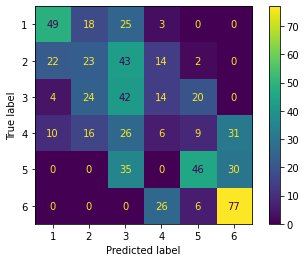

In [152]:
disp_model.plot() 

In [153]:
cm_clf_test=confusion_matrix(Y_test, clf_X_test_pred)

In [154]:
cm_clf_test

array([[ 95,   0,   0,   0,   0,   0],
       [  0, 104,   0,   0,   0,   0],
       [  0,   0, 104,   0,   0,   0],
       [  0,   0,   0,  98,   0,   0],
       [  0,   0,   0,   0, 111,   0],
       [  0,   0,   0,   0,   0, 109]], dtype=int64)

In [155]:
disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test, display_labels=model.classes_)

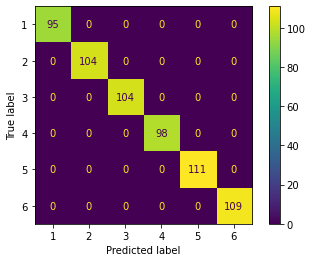

In [156]:
disp_clf.plot() 

In [157]:
cm_knn_test=confusion_matrix(Y_test, knn_X_test_pred)

In [158]:
cm_knn_test

array([[ 72,  19,   2,   2,   0,   0],
       [ 40,  39,  21,   2,   2,   0],
       [  5,  14,  72,  11,   2,   0],
       [  4,   2,   2,  90,   0,   0],
       [  0,   0,   0,   0, 111,   0],
       [  0,   0,   0,   0,   0, 109]], dtype=int64)

In [159]:
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn_test, display_labels=model.classes_)

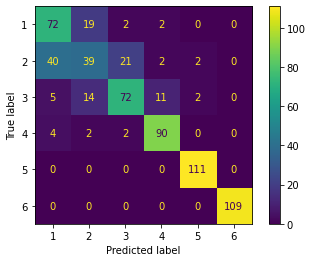

In [160]:
disp_knn.plot()

In [161]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000        95
           2      1.000     1.000     1.000       104
           3      1.000     1.000     1.000       104
           4      1.000     1.000     1.000        98
           5      1.000     1.000     1.000       111
           6      1.000     1.000     1.000       109

    accuracy                          1.000       621
   macro avg      1.000     1.000     1.000       621
weighted avg      1.000     1.000     1.000       621



In [162]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.595     0.758     0.667        95
           2      0.527     0.375     0.438       104
           3      0.742     0.692     0.716       104
           4      0.857     0.918     0.887        98
           5      0.965     1.000     0.982       111
           6      1.000     1.000     1.000       109

    accuracy                          0.794       621
   macro avg      0.781     0.791     0.782       621
weighted avg      0.787     0.794     0.786       621



In [163]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.576     0.516     0.544        95
           2      0.284     0.221     0.249       104
           3      0.246     0.404     0.305       104
           4      0.095     0.061     0.075        98
           5      0.554     0.414     0.474       111
           6      0.558     0.706     0.623       109

    accuracy                          0.391       621
   macro avg      0.386     0.387     0.378       621
weighted avg      0.389     0.391     0.382       621



In [164]:
#model_cvp=cross_val_predict(model, X_test, Y_test, cv=3, method="predict")

In [165]:
#roc_auc_score(Y_test, model_pred_proba, multi_class='ovr')